# Credit Card Fraud Detection
**Models:** Logistic Regression | Random Forest | Neural Network (ANN)

In [1]:
# STEP 1 - Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
# STEP 2 - Load Dataset
df = pd.read_csv('creditcard.csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# STEP 3 - EDA
print(f'Rows         : {df.shape[0]}')
print(f'Columns      : {df.shape[1]}')
print(f'Missing vals : {df.isnull().sum().sum()}')
print(f'Duplicates   : {df.duplicated().sum()}')

fraud_count = df['Class'].value_counts()
print(f'\nNon-Fraud: {fraud_count[0]:,} ({fraud_count[0]/len(df)*100:.2f}%)')
print(f'Fraud    : {fraud_count[1]:,} ({fraud_count[1]/len(df)*100:.2f}%)')

Rows         : 284807
Columns      : 31
Missing vals : 0
Duplicates   : 1081

Non-Fraud: 284,315 (99.83%)
Fraud    : 492 (0.17%)


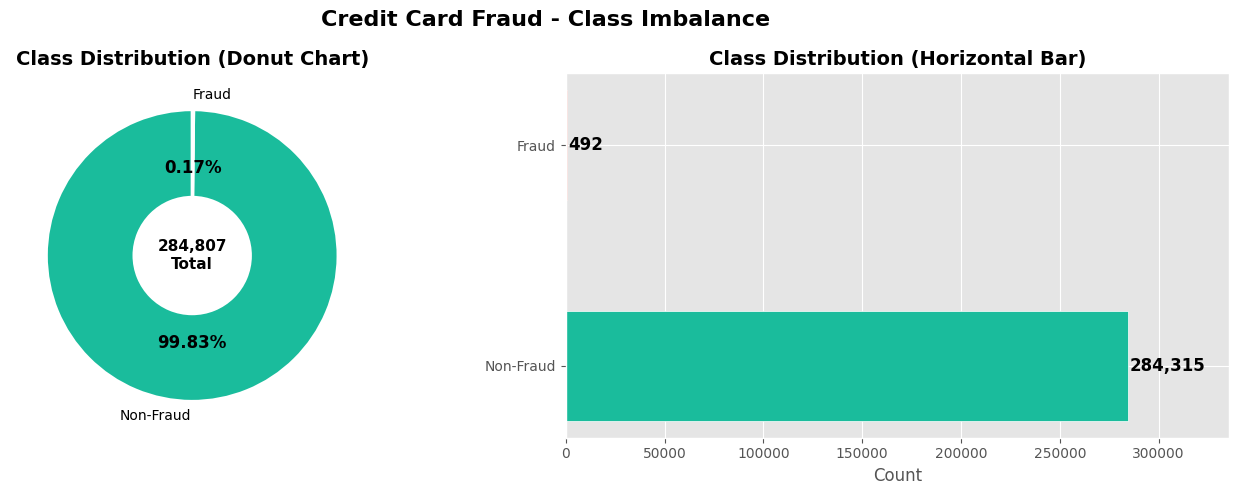

Saved: 01_class_distribution.png


In [4]:
# STEP 3b - Donut Chart + Horizontal Bar Chart
fraud_count = df['Class'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart (pie with white circle in center)
wedges, texts, autotexts = axes[0].pie(
    fraud_count,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.2f%%',
    colors=['#1ABC9C', '#E74C3C'],
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
centre_circle = plt.Circle((0,0), 0.35, fc='white')
axes[0].add_patch(centre_circle)
axes[0].text(0, 0, f'{len(df):,}\nTotal', ha='center', va='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Donut Chart)', fontsize=14, fontweight='bold')

# Horizontal bar chart
hbars = axes[1].barh(['Non-Fraud', 'Fraud'], fraud_count.values,
    color=['#1ABC9C', '#E74C3C'], edgecolor='white', height=0.5)
for bar in hbars:
    axes[1].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,}', va='center', fontsize=12, fontweight='bold')
axes[1].set_title('Class Distribution (Horizontal Bar)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_xlim(0, fraud_count.max() * 1.18)

plt.suptitle('Credit Card Fraud - Class Imbalance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_class_distribution.png')

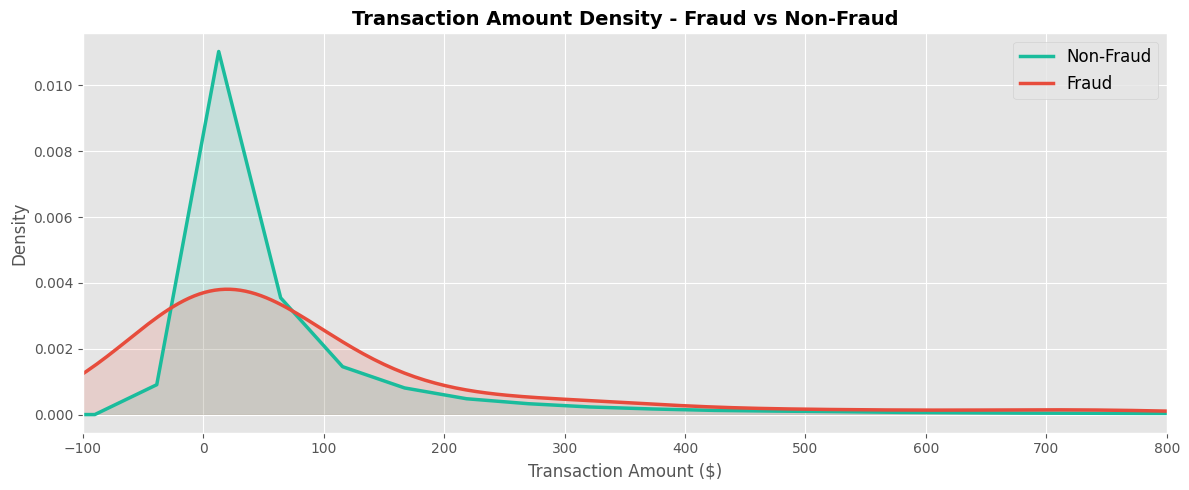

Saved: 02_amount_distribution.png


In [5]:
# STEP 3c - KDE (Density) Plot for Amount
fig, ax = plt.subplots(figsize=(12, 5))

df[df['Class']==0]['Amount'].plot.kde(ax=ax, color='#1ABC9C', linewidth=2.5, label='Non-Fraud')
df[df['Class']==1]['Amount'].plot.kde(ax=ax, color='#E74C3C', linewidth=2.5, label='Fraud')

ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.15, color='#1ABC9C')
ax.fill_between(ax.lines[1].get_xdata(), ax.lines[1].get_ydata(), alpha=0.15, color='#E74C3C')

ax.set_xlim(-100, 800)
ax.set_title('Transaction Amount Density - Fraud vs Non-Fraud', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Density')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_amount_distribution.png')

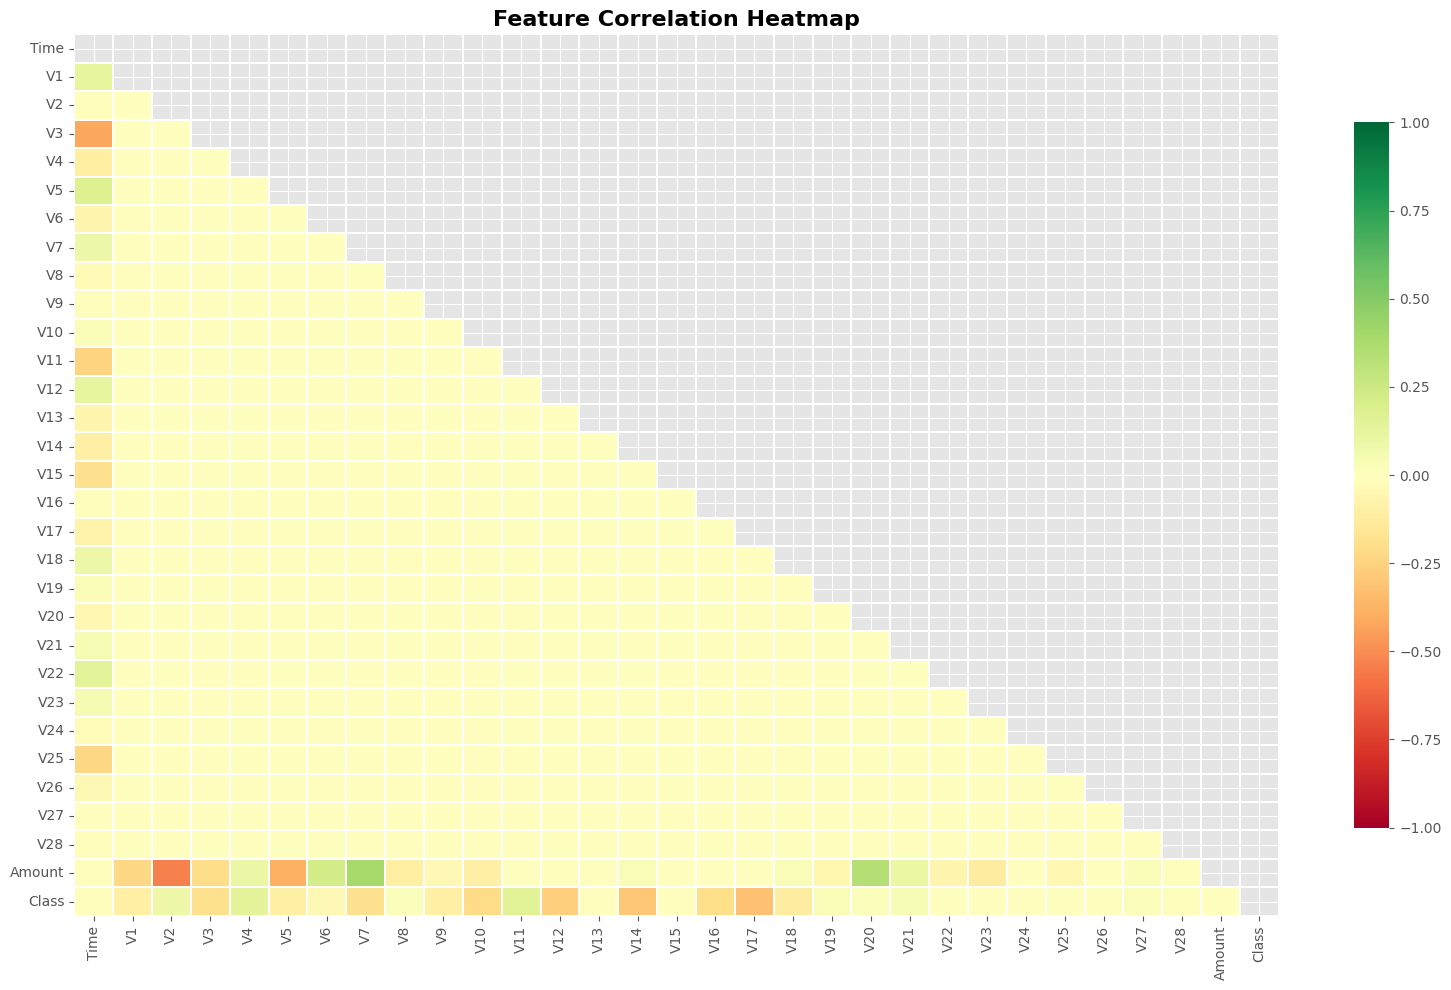

Saved: 03_correlation_heatmap.png


In [6]:
# STEP 3d - Correlation Heatmap (different colormap)
plt.figure(figsize=(16, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn',
    linewidths=0.2, vmin=-1, vmax=1, center=0,
    square=False, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_correlation_heatmap.png')

In [7]:
# STEP 4 - Data Cleaning & Preprocessing
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicates')

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df.drop(columns=['Amount','Time'], inplace=True)

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Removed 1081 duplicates
Training set : 226980 samples
Test set     : 56746 samples


SMOTE applied!
Class
0    226602
1     22660
Name: count, dtype: int64


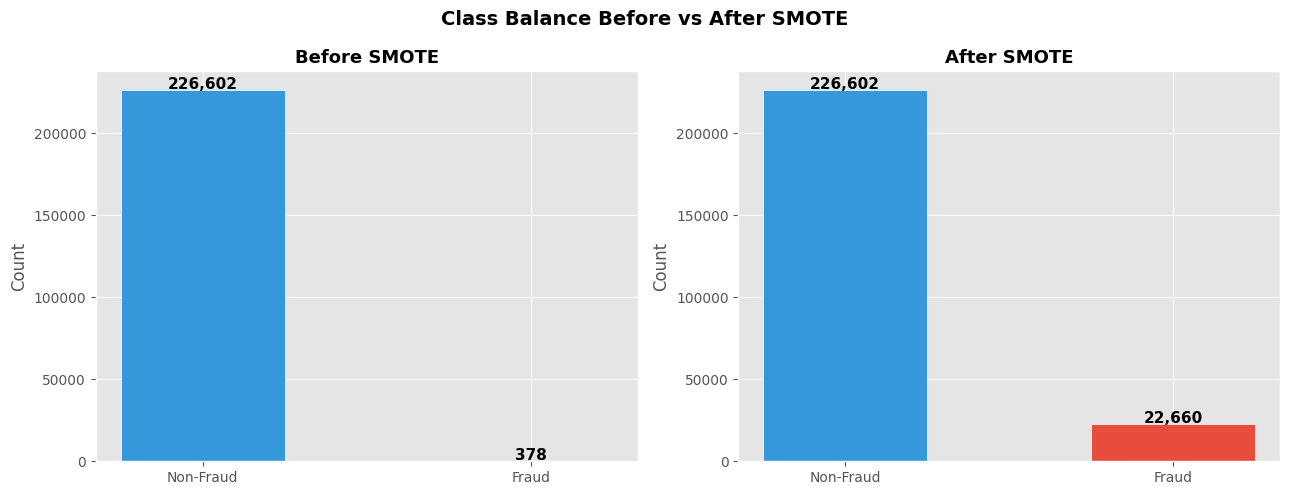

Saved: 04_smote_balance.png


In [8]:
# STEP 4b - Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.1, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('SMOTE applied!')
print(pd.Series(y_train_sm).value_counts())

# Stacked bar chart style for SMOTE comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

before_counts = pd.Series(y_train).value_counts().sort_index()
after_counts  = pd.Series(y_train_sm).value_counts().sort_index()

categories = ['Non-Fraud', 'Fraud']
x = np.arange(len(categories))

axes[0].bar(categories, before_counts.values, color=['#3498DB','#E74C3C'], edgecolor='white', width=0.5)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(categories, after_counts.values, color=['#3498DB','#E74C3C'], edgecolor='white', width=0.5)
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Balance Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_smote_balance.png')

## Model 1 - Logistic Regression

In [9]:
# STEP 5 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print('='*45)
print('      LOGISTIC REGRESSION RESULTS')
print('='*45)
print(f'  Accuracy  : {lr_acc:.4f}')
print(f'  Precision : {lr_prec:.4f}')
print(f'  Recall    : {lr_rec:.4f}')
print(f'  F1-Score  : {lr_f1:.4f}')
print('='*45)
print(classification_report(y_test, lr_pred, target_names=['Non-Fraud','Fraud']))

      LOGISTIC REGRESSION RESULTS
  Accuracy  : 0.9978
  Precision : 0.4199
  Recall    : 0.8000
  F1-Score  : 0.5507
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.42      0.80      0.55        95

    accuracy                           1.00     56746
   macro avg       0.71      0.90      0.77     56746
weighted avg       1.00      1.00      1.00     56746



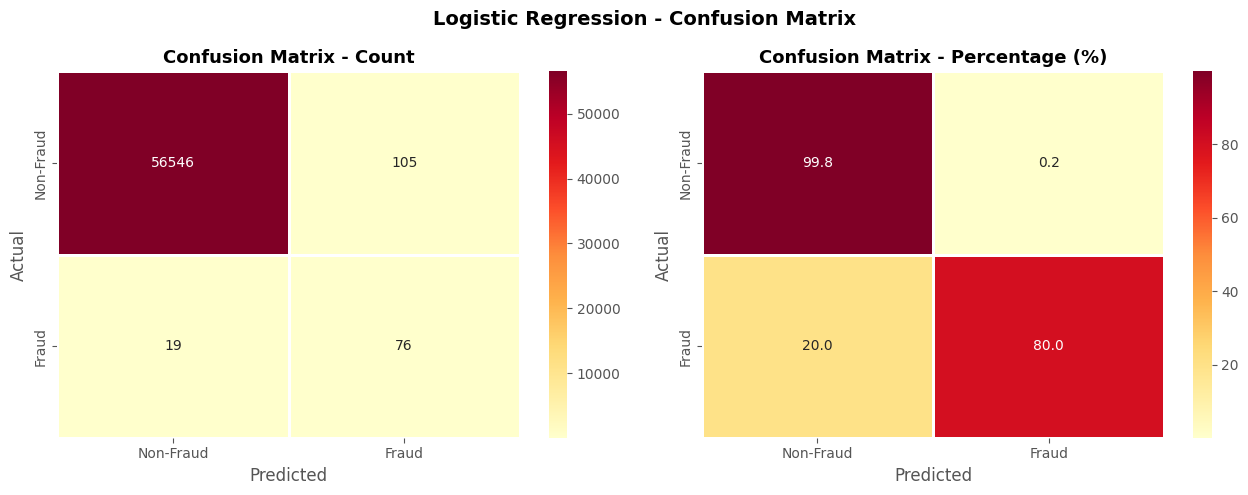

In [10]:
# Confusion Matrix - Logistic Regression (annotated with %)
cm_lr = confusion_matrix(y_test, lr_pred)
cm_lr_pct = cm_lr.astype('float') / cm_lr.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'],
    linewidths=2, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix - Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_lr_pct, annot=True, fmt='.1f', cmap='YlOrRd',
    xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'],
    linewidths=2, linecolor='white', ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentage (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_cm_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 2 - Random Forest

In [11]:
# STEP 6 - Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50, random_state=42,
    class_weight='balanced', n_jobs=-1, max_depth=10)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print('='*45)
print('          RANDOM FOREST RESULTS')
print('='*45)
print(f'  Accuracy  : {rf_acc:.4f}')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print('='*45)
print(classification_report(y_test, rf_pred, target_names=['Non-Fraud','Fraud']))

          RANDOM FOREST RESULTS
  Accuracy  : 0.9987
  Precision : 0.5736
  Recall    : 0.7789
  F1-Score  : 0.6607
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.57      0.78      0.66        95

    accuracy                           1.00     56746
   macro avg       0.79      0.89      0.83     56746
weighted avg       1.00      1.00      1.00     56746



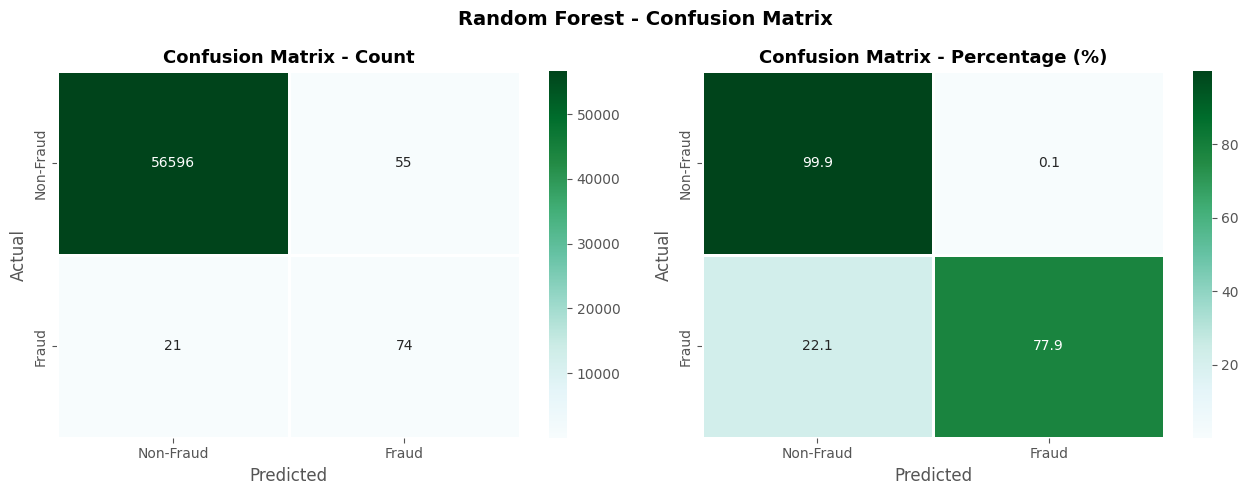

In [12]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
cm_rf_pct = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='BuGn',
    xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'],
    linewidths=2, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix - Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_rf_pct, annot=True, fmt='.1f', cmap='BuGn',
    xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'],
    linewidths=2, linecolor='white', ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentage (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_cm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

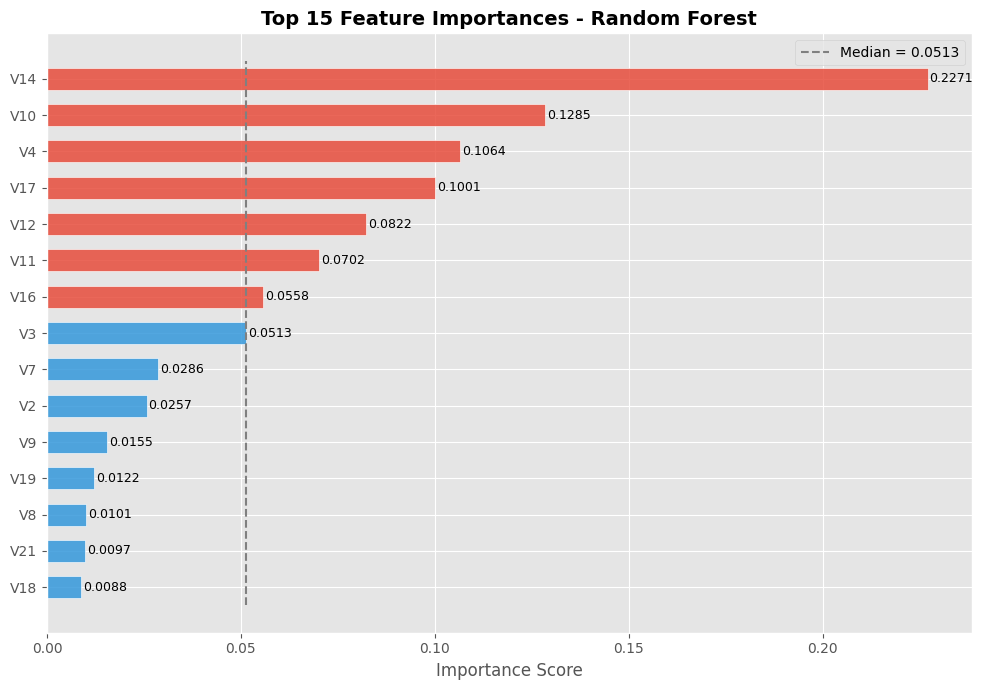

Saved: 07_feature_importance.png


In [13]:
# Feature Importance - Lollipop Chart style
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#E74C3C' if v > top15.median() else '#3498DB' for v in top15.values]
ax.barh(top15.index, top15.values, color=colors_imp, edgecolor='white', height=0.6, alpha=0.85)
ax.vlines(top15.median(), -0.5, len(top15)-0.5, colors='gray', linestyles='dashed', linewidth=1.5, label=f'Median = {top15.median():.4f}')
for i, (val, name) in enumerate(zip(top15.values, top15.index)):
    ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Top 15 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_feature_importance.png')

## Model 3 - Neural Network (ANN)

In [14]:
# STEP 7 - Neural Network (ANN)
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu', solver='adam',
    max_iter=50, random_state=42,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=5, verbose=False)
ann_model.fit(X_train_sm, y_train_sm)

ann_pred = ann_model.predict(X_test)
ann_prob = ann_model.predict_proba(X_test)[:,1]

ann_acc  = accuracy_score(y_test, ann_pred)
ann_prec = precision_score(y_test, ann_pred)
ann_rec  = recall_score(y_test, ann_pred)
ann_f1   = f1_score(y_test, ann_pred)

print('='*45)
print('     NEURAL NETWORK (ANN) RESULTS')
print('='*45)
print(f'  Accuracy  : {ann_acc:.4f}')
print(f'  Precision : {ann_prec:.4f}')
print(f'  Recall    : {ann_rec:.4f}')
print(f'  F1-Score  : {ann_f1:.4f}')
print('='*45)
print(classification_report(y_test, ann_pred, target_names=['Non-Fraud','Fraud']))

     NEURAL NETWORK (ANN) RESULTS
  Accuracy  : 0.9992
  Precision : 0.7426
  Recall    : 0.7895
  F1-Score  : 0.7653
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.74      0.79      0.77        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



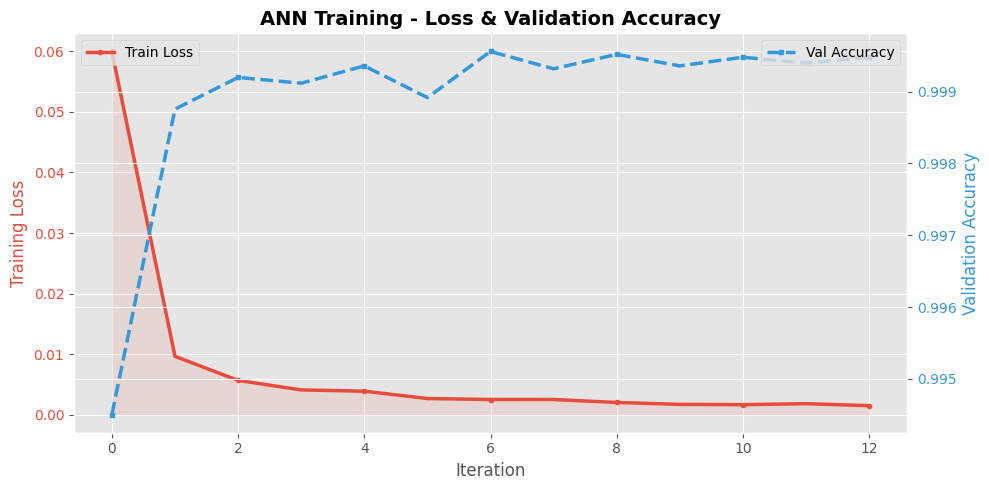

Saved: 08_ann_history.png


In [15]:
# ANN Loss Curve - Dual axis style
fig, ax1 = plt.subplots(figsize=(10, 5))

color_train = '#E74C3C'
ax1.plot(ann_model.loss_curve_, color=color_train, linewidth=2.5, marker='o',
    markersize=3, label='Train Loss', markevery=2)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Training Loss', color=color_train, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_train)
ax1.fill_between(range(len(ann_model.loss_curve_)), ann_model.loss_curve_, alpha=0.1, color=color_train)

if ann_model.validation_scores_ is not None:
    ax2 = ax1.twinx()
    ax2.plot(ann_model.validation_scores_, color='#3498DB', linewidth=2.5,
        linestyle='--', marker='s', markersize=3, label='Val Accuracy', markevery=2)
    ax2.set_ylabel('Validation Accuracy', color='#3498DB', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='#3498DB')
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(loc='upper left', fontsize=10)
    ax2.legend(loc='upper right', fontsize=10)

plt.title('ANN Training - Loss & Validation Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_ann_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_ann_history.png')

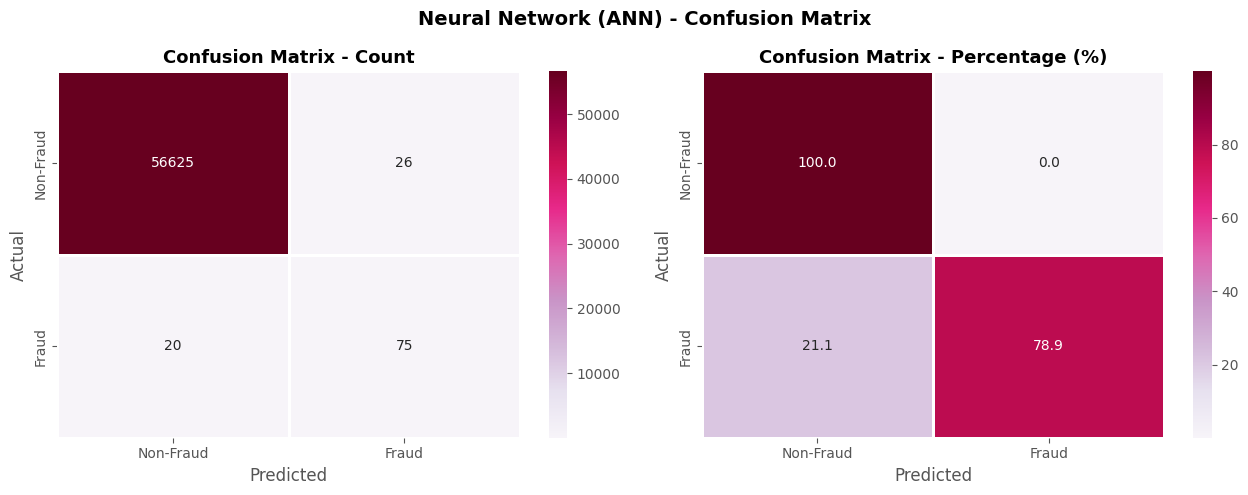

In [16]:
# Confusion Matrix - ANN
cm_ann = confusion_matrix(y_test, ann_pred)
cm_ann_pct = cm_ann.astype('float') / cm_ann.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='PuRd',
    xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'],
    linewidths=2, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix - Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_ann_pct, annot=True, fmt='.1f', cmap='PuRd',
    xticklabels=['Non-Fraud','Fraud'], yticklabels=['Non-Fraud','Fraud'],
    linewidths=2, linecolor='white', ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentage (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Neural Network (ANN) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_cm_ann.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 - Model Comparison & Evaluation

In [17]:
# STEP 8 - Comparison Table
results = pd.DataFrame({
    'Model':     ['Logistic Regression','Random Forest','Neural Network (ANN)'],
    'Accuracy':  [lr_acc,  rf_acc,  ann_acc],
    'Precision': [lr_prec, rf_prec, ann_prec],
    'Recall':    [lr_rec,  rf_rec,  ann_rec],
    'F1-Score':  [lr_f1,   rf_f1,   ann_f1]
}).set_index('Model').round(4)

print('='*65)
print('            MODEL COMPARISON TABLE')
print('='*65)
print(results.to_string())
print('='*65)
best = results['F1-Score'].idxmax()
print(f'\nBest Model: {best} (F1={results.loc[best,"F1-Score"]:.4f})')

            MODEL COMPARISON TABLE
                      Accuracy  Precision  Recall  F1-Score
Model                                                      
Logistic Regression     0.9978     0.4199  0.8000    0.5507
Random Forest           0.9987     0.5736  0.7789    0.6607
Neural Network (ANN)    0.9992     0.7426  0.7895    0.7653

Best Model: Neural Network (ANN) (F1=0.7653)


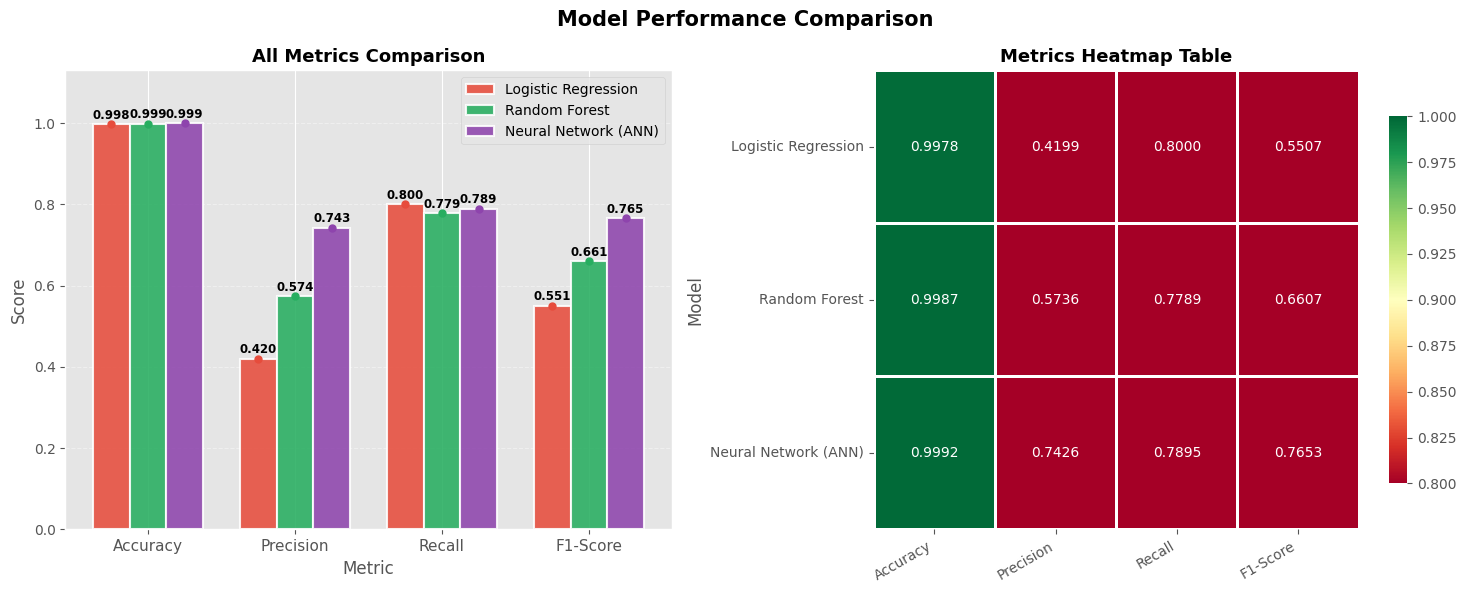

Saved: 10_model_comparison.png


In [18]:
# Radar / Spider Chart Style - Model Comparison
from matplotlib.patches import FancyArrowPatch

metrics = ['Accuracy','Precision','Recall','F1-Score']
models  = results.index.tolist()
colors  = ['#E74C3C','#27AE60','#8E44AD']

x = np.arange(len(metrics))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grouped bar with step lines
for i,(model,color) in enumerate(zip(models,colors)):
    vals = results.loc[model, metrics].values
    bars = axes[0].bar(x+i*width, vals, width, label=model, color=color,
        edgecolor='white', alpha=0.88, linewidth=1.5)
    axes[0].plot(x+i*width, vals, 'o', color=color, markersize=5, zorder=5)
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

axes[0].set_xlabel('Metric', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('All Metrics Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x+width)
axes[0].set_xticklabels(metrics, fontsize=11)
axes[0].set_ylim(0, 1.13)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.4, linestyle='--')

# Heatmap table of results
sns.heatmap(results, annot=True, fmt='.4f', cmap='RdYlGn',
    linewidths=1, linecolor='white', ax=axes[1],
    vmin=0.8, vmax=1.0, cbar_kws={'shrink':0.8})
axes[1].set_title('Metrics Heatmap Table', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_model_comparison.png')

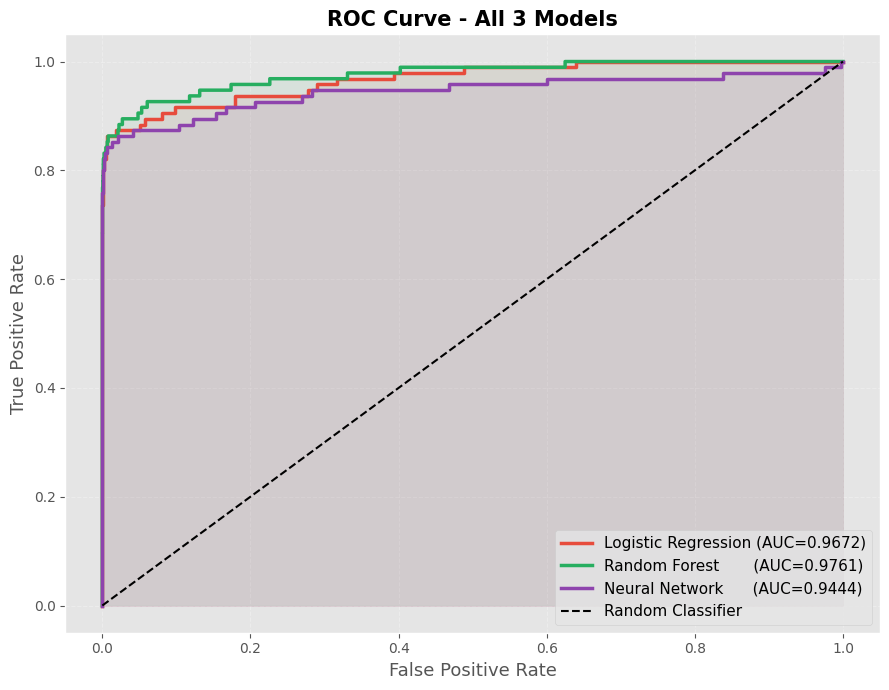

Saved: 11_roc_curves.png


In [19]:
# ROC Curves with shaded area
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_prob)

auc_lr  = auc(fpr_lr,  tpr_lr)
auc_rf  = auc(fpr_rf,  tpr_rf)
auc_ann = auc(fpr_ann, tpr_ann)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC={auc_lr:.4f})',  color='#E74C3C', linewidth=2.5)
ax.plot(fpr_rf,  tpr_rf,  label=f'Random Forest       (AUC={auc_rf:.4f})',  color='#27AE60', linewidth=2.5)
ax.plot(fpr_ann, tpr_ann, label=f'Neural Network      (AUC={auc_ann:.4f})', color='#8E44AD', linewidth=2.5)
ax.fill_between(fpr_lr,  tpr_lr,  alpha=0.07, color='#E74C3C')
ax.fill_between(fpr_rf,  tpr_rf,  alpha=0.07, color='#27AE60')
ax.fill_between(fpr_ann, tpr_ann, alpha=0.07, color='#8E44AD')
ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('ROC Curve - All 3 Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_roc_curves.png')

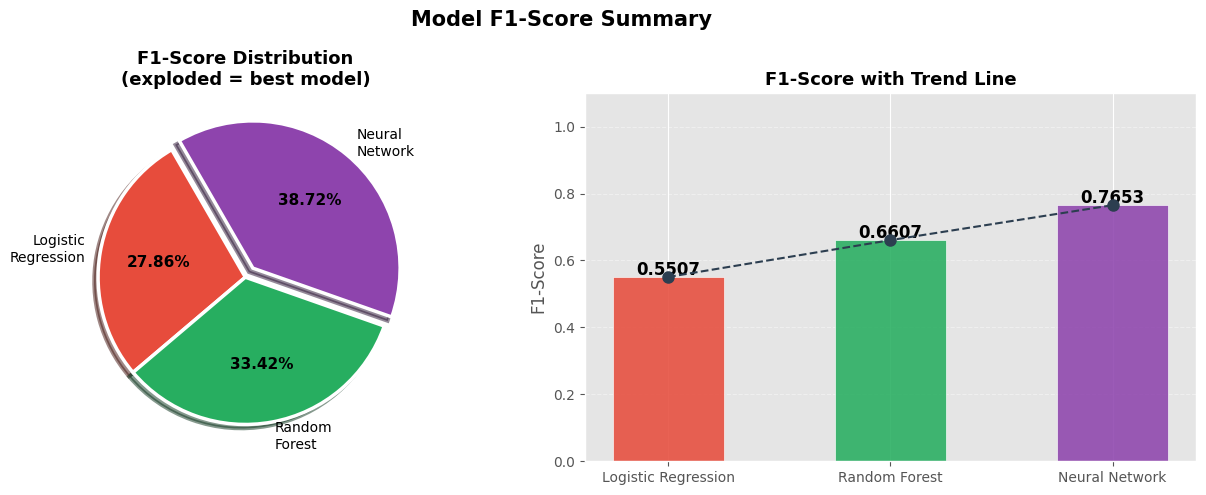

Saved: 12_f1_summary.png


In [20]:
# F1 Score - Exploded Pie + Step Bar
f1_scores   = [lr_f1, rf_f1, ann_f1]
model_names = ['Logistic\nRegression','Random\nForest','Neural\nNetwork']
colors_pie  = ['#E74C3C','#27AE60','#8E44AD']
best_idx    = f1_scores.index(max(f1_scores))
explode     = [0.08 if i == best_idx else 0 for i in range(3)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

wedges, texts, autotexts = axes[0].pie(
    f1_scores, labels=model_names, autopct='%1.2f%%',
    colors=colors_pie, startangle=120, explode=explode,
    wedgeprops={'edgecolor':'white','linewidth':2.5},
    shadow=True
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[0].set_title('F1-Score Distribution\n(exploded = best model)', fontsize=13, fontweight='bold')

bar_colors = ['#E74C3C','#27AE60','#8E44AD']
bars = axes[1].bar(['Logistic Regression','Random Forest','Neural Network'],
    f1_scores, color=bar_colors, edgecolor='white', alpha=0.88, width=0.5)
axes[1].plot(['Logistic Regression','Random Forest','Neural Network'],
    f1_scores, 'o--', color='#2C3E50', linewidth=1.5, markersize=8, zorder=5)
for bar, val in zip(bars, f1_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
        f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score with Trend Line', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.4, linestyle='--')

plt.suptitle('Model F1-Score Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('12_f1_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_f1_summary.png')

## Step 9 - Best Model for Deployment

In [21]:
# STEP 9 - Final Verdict
print('='*55)
print('       FINAL MODEL EVALUATION SUMMARY')
print('='*55)
print(results.to_string())
print('='*55)
best = results['F1-Score'].idxmax()
print(f'''
BEST MODEL FOR DEPLOYMENT: {best}
  - Highest F1-Score (balanced precision and recall)
  - For fraud detection, Recall is critical
  - Deployment date: April 13, 2026
''')

       FINAL MODEL EVALUATION SUMMARY
                      Accuracy  Precision  Recall  F1-Score
Model                                                      
Logistic Regression     0.9978     0.4199  0.8000    0.5507
Random Forest           0.9987     0.5736  0.7789    0.6607
Neural Network (ANN)    0.9992     0.7426  0.7895    0.7653

BEST MODEL FOR DEPLOYMENT: Neural Network (ANN)
  - Highest F1-Score (balanced precision and recall)
  - For fraud detection, Recall is critical
  - Deployment date: April 13, 2026

